# Valoración del suelo del ámbito — Sector 35, Santa Cruz de Bezana

**Objetivo:** estimar el coste de adquisición del suelo del ámbito objeto del proyecto (9.290 m² brutos en Santa Cruz de Bezana, junto al casco urbano consolidado) mediante la aplicación de los modelos de aprendizaje automático entrenados en los notebooks anteriores (`61_linear_regression`, `62_random_forest`, `63_boost`) sobre el dataset `data/gold/final_land_scraping.csv`.

**Motivación metodológica:** la estimación a partir de un único modelo es vulnerable a sus limitaciones específicas (sesgo lineal de Ridge/Lasso, varianza alta de modelos de árboles en regiones de baja densidad de datos). Se recurre por tanto a un esquema de *triangulación de modelos*, en el que el valor finalmente adoptado deriva de la mediana de las predicciones de los cinco modelos, sin ajustes hedónicos adicionales en esta versión.

**Estructura del notebook:**

1. Carga de datos y verificación del encoding del municipio
2. Entrenamiento de los cinco modelos (réplica de 61/62/63)
3. Comparativa de rendimiento
4. Definición del input del ámbito (Sector 35)
5. Predicciones y agregación de resultados
6. Ajustes hedónicos por características no observadas
7. Valor final adoptado
8. Discusión metodológica y limitaciones

**Hipótesis previa sobre el rendimiento esperado:** dado que el dataset cuenta con sólo 7 features y que la correlación de `superficie_m2` con el target es marginal (r ≈ 0.07), no se espera un R² elevado en ninguno de los modelos. La triangulación pretende precisamente atenuar la incertidumbre individual de cada modelo. La capacidad real del esquema reside en proporcionar un *orden de magnitud* defendible empíricamente, no una predicción puntual exacta.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Carga de datos

Se carga un unico artefacto generado en el pipeline de feature engineering:

- **`final_land_scraping.csv`**: dataset procesado utilizado para entrenar los modelos. El notebook deriva de este CSV tanto las features disponibles como las dummies de `tipo_suelo`, sin depender de JSON auxiliares en `data/gold/`.

El artefacto vive en `data/gold/` por convencion del proyecto. **El dataset bruto `scraping_land_raw.csv` no se utiliza en este notebook**, garantizando que tanto el entrenamiento como la prediccion operan exclusivamente sobre datos ya procesados y validados.


In [41]:
# Dataset procesado (input de los modelos)
df = pd.read_csv('../../data/gold/final_land_scraping.csv')

print(f'Dataset procesado: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

# El notebook usa exclusivamente el propio CSV gold para detectar
# las features disponibles en tiempo de ejecucion.


Dataset procesado: (48, 6)
Columnas: ['precio_eur', 'superficie_m2', 'log_precio', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano', 'tipo_suelo_Urbano (solar)']


## 2. Train/test split

Se aplica el mismo split (80/20, `random_state=42`) utilizado en los notebooks anteriores, garantizando que las métricas obtenidas en este notebook sean directamente comparables con las reportadas en `61_linear_regression`, `62_random_forest` y `63_boost`.


In [42]:
TARGET = 'log_precio'
EXCLUDE = ['precio_eur', TARGET]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')


def get_metrics(model, name=''):
    """Métricas en el conjunto de test, con detalle por escenario de suelo."""
    y_pred = model.predict(X_test)
    m = {
        'R2_test':   r2_score(y_test, y_pred),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE_test':  mean_absolute_error(y_test, y_pred),
    }

    scenario_columns = {
        'urbanizable': next((c for c in FEATURES if c == 'tipo_suelo_Urbanizable'), None),
    }

    for scenario_name, scenario_col in scenario_columns.items():
        if scenario_col is None or scenario_col not in X_test.columns:
            continue
        mask = X_test[scenario_col] == 1
        if mask.sum() < 2:
            continue
        y_true_scenario = y_test[mask]
        y_pred_scenario = y_pred[mask]
        m[f'R2_test_{scenario_name}'] = r2_score(y_true_scenario, y_pred_scenario)

    if name:
        extra = []
        if 'R2_test_urbanizable' in m:
            extra.append(f"R² urbanizable={m['R2_test_urbanizable']:.4f}")
        extra_txt = ' | ' + ' | '.join(extra) if extra else ''
        print(f'  {name:<22}  R²={m["R2_test"]:.4f}  RMSE={m["RMSE_test"]:.4f}  MAE={m["MAE_test"]:.4f}{extra_txt}')
    return m


Train: (38, 4) | Test: (10, 4)
Features (4): ['superficie_m2', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano', 'tipo_suelo_Urbano (solar)']


## 3. Entrenamiento de los cinco modelos

Se entrenan secuencialmente cinco modelos previamente validados: Ridge, Lasso, Random Forest, Extra Trees y XGBoost. La diversidad metodológica (lineal, bagging, boosting) reduce el riesgo de sesgos sistemáticos compartidos. Los modelos no lineales se optimizan con Optuna y validación cruzada de 5 folds.

### 3.1. Ridge

In [43]:
alphas = np.logspace(-4, 4, 80)

ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
ridge_gs = GridSearchCV(ridge_pipe, {'ridge__alpha': alphas}, cv=5,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
ridge = ridge_gs.best_estimator_

print(f'Mejor α Ridge: {ridge_gs.best_params_["ridge__alpha"]:.4f}')
m_ridge = get_metrics(ridge, 'Ridge')


Mejor α Ridge: 23.2857
  Ridge                   R²=0.2779  RMSE=0.7027  MAE=0.6483


### 3.2. Lasso

In [44]:
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=20000))])
lasso_gs = GridSearchCV(lasso_pipe, {'lasso__alpha': alphas}, cv=5,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)
lasso = lasso_gs.best_estimator_

# Features descartadas por Lasso
lasso_coefs = pd.Series(lasso.named_steps['lasso'].coef_, index=FEATURES)
zeroed = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f'Mejor α Lasso: {lasso_gs.best_params_["lasso__alpha"]:.4f}')
print(f'Features descartadas por Lasso: {zeroed if zeroed else "ninguna"}')
m_lasso = get_metrics(lasso, 'Lasso')


Mejor α Lasso: 0.2197
Features descartadas por Lasso: ['tipo_suelo_Urbanizable', 'tipo_suelo_Urbano', 'tipo_suelo_Urbano (solar)']
  Lasso                   R²=0.3416  RMSE=0.6710  MAE=0.6144


### 3.3. Random Forest (Optuna)

In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    }
    m = RandomForestRegressor(**params)
    s = cross_val_score(m, X_train, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -s.mean()

study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(objective_rf, n_trials=40, show_progress_bar=False)

rf = RandomForestRegressor(**{**study_rf.best_params,
                              'random_state': RANDOM_STATE, 'n_jobs': -1})
rf.fit(X_train, y_train)
print(f'Mejor RMSE CV: {study_rf.best_value:.4f}')
m_rf = get_metrics(rf, 'Random Forest')


Mejor RMSE CV: 0.5497
  Random Forest           R²=0.6507  RMSE=0.4888  MAE=0.4536


### 3.4. Extra Trees (Optuna)

In [46]:
def objective_et(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    }
    m = ExtraTreesRegressor(**params)
    s = cross_val_score(m, X_train, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -s.mean()

study_et = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(objective_et, n_trials=40, show_progress_bar=False)

et = ExtraTreesRegressor(**{**study_et.best_params,
                            'random_state': RANDOM_STATE, 'n_jobs': -1})
et.fit(X_train, y_train)
print(f'Mejor RMSE CV: {study_et.best_value:.4f}')
m_et = get_metrics(et, 'Extra Trees')


Mejor RMSE CV: 0.5588
  Extra Trees             R²=0.7150  RMSE=0.4415  MAE=0.3872


### 3.5. XGBoost (Optuna)

In [47]:
def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0,
    }
    m = XGBRegressor(**params)
    s = cross_val_score(m, X_train, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -s.mean()

study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=False)

xgb = XGBRegressor(**{**study_xgb.best_params, 'random_state': RANDOM_STATE,
                       'n_jobs': -1, 'verbosity': 0})
xgb.fit(X_train, y_train)
print(f'Mejor RMSE CV: {study_xgb.best_value:.4f}')
m_xgb = get_metrics(xgb, 'XGBoost')


Mejor RMSE CV: 0.3784
  XGBoost                 R²=0.7889  RMSE=0.3800  MAE=0.2410


## 4. Comparativa de rendimiento

A continuación se consolidan las métricas de los cinco modelos sobre el conjunto de test. La métrica principal es el R² ajustado por test, que indica la fracción de variabilidad de `log_precio` explicada por el modelo.

In [48]:
# Comparativa de rendimiento (test set)
metricas = {
    'Ridge': m_ridge,
    'Lasso': m_lasso,
    'Random Forest': m_rf,
    'Extra Trees': m_et,
    'XGBoost': m_xgb,
}

metricas_df = pd.DataFrame(metricas).T.round(4)
resumen = metricas_df
print('Comparativa de rendimiento (test set):')
print(metricas_df)

Comparativa de rendimiento (test set):
               R2_test  RMSE_test  MAE_test
Ridge           0.2779     0.7027    0.6483
Lasso           0.3416     0.6710    0.6144
Random Forest   0.6507     0.4888    0.4536
Extra Trees     0.7150     0.4415    0.3872
XGBoost         0.7889     0.3800    0.2410


**Lectura del rendimiento.** Los R² obtenidos (entre ≈0,30 y ≈0,40) reflejan que el conjunto de features disponible explica únicamente entre el 30 % y el 40 % de la variabilidad logarítmica del precio. Esta limitación es estructural del dataset: con sólo 7 features y una variable explicativa principal (`superficie_m2`) débilmente correlacionada con el precio, ningún modelo puede alcanzar un R² alto. Esto refuerza la justificación metodológica de combinar los cinco modelos en lugar de confiar en una predicción única, y de complementar las predicciones con ajustes hedónicos por características no observadas.


## 5. Definición del input del ámbito

El ámbito objeto del proyecto presenta las siguientes características:

| Atributo | Valor |
|---|---|
| Municipio | Santa Cruz de Bezana |
| Superficie bruta | 9.290 m² |
| Calificación urbanística actual | Pendiente de recalificación a urbanizable mediante modificación puntual del planeamiento |
| Calificación post-recalificación | U2 — vivienda unifamiliar (edificabilidad 0,45 m²/m²) |
| Ubicación dentro del municipio | Casco urbano consolidado de Bezana, junto a la iglesia |

Se generan predicciones para **suelo urbanizable** y **suelo urbano (solar)** para comparar ambos escenarios. Si en el dataset entrenado no existe la categoría urbanizable, se informa y se mantiene únicamente el escenario urbano (solar).

In [49]:
# Deteccion dinamica de las columnas one-hot de tipo_suelo presentes
# en el dataset, evitando hardcodear nombres que cambiarian si el
# pipeline de feature engineering se ajusta en el futuro.
COLS_TIPO_SUELO = sorted([c for c in FEATURES if c.startswith('tipo_suelo_')])
print('Columnas one-hot de tipo_suelo detectadas:')
for c in COLS_TIPO_SUELO:
    print(f'  - {c}')

# Mapeo entre alias semanticos y nombres reales de columnas. El dataset
# diferencia entre 'Urbano' (generico) y 'Urbano (solar)' (solar finalista
# listo para edificar). El ambito objeto del proyecto, una vez completada
# la modificacion del planeamiento, encajaria en la categoria 'Urbano (solar)'.
def localizar_columna(patron_busqueda):
    """Busca la columna de tipo_suelo cuyo nombre contiene el patron dado."""
    coincidencias = [c for c in COLS_TIPO_SUELO if patron_busqueda.lower() in c.lower()]
    if not coincidencias:
        return None
    return coincidencias[0]

ALIAS_A_COLUMNA = {
    'no_urbanizable':   localizar_columna('no urbanizable'),
    'urbanizable':      next((c for c in COLS_TIPO_SUELO
                              if 'urbanizable' in c.lower() and 'no' not in c.lower()), None),
    'urbano':           next((c for c in COLS_TIPO_SUELO
                              if c.lower() == 'tipo_suelo_urbano'), None),
    'urbano_solar':     next((c for c in COLS_TIPO_SUELO
                              if 'solar' in c.lower()), None),
}
print('\nMapeo alias -> columna real:')
for alias, col in ALIAS_A_COLUMNA.items():
    print(f'  {alias:<20} -> {col}')


def construir_input(superficie, tipo, vendido_descuento=0):
    """
    Genera la fila de features para prediccion.

    Parametros
    ----------
    superficie       : float        Superficie bruta del ambito (m2)
    tipo             : str          Alias del tipo de suelo. Valores admitidos:
                                    'urbano_solar', 'urbano', 'urbanizable', 'no_urbanizable'
    vendido_descuento: int          Indicador binario (0/1). Solo se usa si esa feature existe.
    """
    if tipo not in ALIAS_A_COLUMNA:
        raise ValueError(f'tipo no reconocido: {tipo!r}. Admitidos: {list(ALIAS_A_COLUMNA)}')
    columna_activa = ALIAS_A_COLUMNA[tipo]
    if columna_activa is None:
        raise ValueError(f'la categoria {tipo!r} no existe en el dataset entrenado')

    # Construimos la fila respetando solo las features realmente presentes
    # en el dataset entrenado actual.
    fila = {col: 0 for col in FEATURES}

    valores_dinamicos = {
        'superficie_m2': float(superficie),
        'vendido_con_descuento': int(vendido_descuento),
        'es_urbano_o_urbanizable': int(tipo in ('urbano', 'urbanizable', 'urbano_solar')),
    }

    for col, valor in valores_dinamicos.items():
        if col in fila:
            fila[col] = valor

    if columna_activa not in fila:
        raise ValueError(f'la columna {columna_activa!r} no existe en las features del modelo actual')
    fila[columna_activa] = 1

    # Devolver DataFrame respetando el orden de FEATURES (sin precio_eur ni log_precio)
    df_input = pd.DataFrame([fila], columns=FEATURES)
    return df_input


X_pred_urb = construir_input(9290, 'urbano_solar')
print('\nInput del ambito (urbano solar):')
print(X_pred_urb.T)

if ALIAS_A_COLUMNA.get('urbanizable') is None:
    X_pred_urbz = None
    print('\nAviso: no existe la categoria urbanizable en el dataset entrenado.')
else:
    X_pred_urbz = construir_input(9290, 'urbanizable')
    print('\nInput del ambito (urbanizable):')
    print(X_pred_urbz.T)


Columnas one-hot de tipo_suelo detectadas:
  - tipo_suelo_Urbanizable
  - tipo_suelo_Urbano
  - tipo_suelo_Urbano (solar)

Mapeo alias -> columna real:
  no_urbanizable       -> None
  urbanizable          -> tipo_suelo_Urbanizable
  urbano               -> tipo_suelo_Urbano
  urbano_solar         -> tipo_suelo_Urbano (solar)

Input del ambito (urbano solar):
                                0
superficie_m2              9290.0
tipo_suelo_Urbanizable        0.0
tipo_suelo_Urbano             0.0
tipo_suelo_Urbano (solar)     1.0

Input del ambito (urbanizable):
                                0
superficie_m2              9290.0
tipo_suelo_Urbanizable        1.0
tipo_suelo_Urbano             0.0
tipo_suelo_Urbano (solar)     0.0


## 6. Predicciones y agregación

Los cinco modelos predicen `log_precio` para el ámbito en **suelo urbano (solar)** y, cuando esté disponible, en **suelo urbanizable**. El resultado se transforma a euros mediante exponenciación y se reporta como precio total y como repercusión por m² bruto.

**Esquema de agregación.** Se adopta la **mediana** de las predicciones con R2>0.6 como estimador central. La mediana se prefiere a la media por ser más robusta ante valores extremos: si uno de los modelos produce una predicción atípica por sobreajuste o por extrapolación más allá del soporte de los datos de entrenamiento, la mediana queda inalterada.

In [50]:
modelos = {
    'Ridge':         ridge,
    'Lasso':         lasso,
    'Random Forest': rf,
    'Extra Trees':   et,
    'XGBoost':       xgb,
}

has_urbanizable = X_pred_urbz is not None

filas = []
for nombre, m in modelos.items():
    p_urb = float(np.exp(m.predict(X_pred_urb)[0]))
    fila = {
        'Modelo': nombre,
        'R²_test global':  resumen.loc[nombre, 'R2_test'],
        'Predicción urbano (€)':     p_urb,
        'Repercusión urbano (€/m²)': p_urb / 9290,
    }
    if has_urbanizable:
        p_urbz = float(np.exp(m.predict(X_pred_urbz)[0]))
        fila['Predicción urbanizable (€)'] = p_urbz
        fila['Repercusión urbanizable (€/m²)'] = p_urbz / 9290
    if f'R2_test_urbanizable' in resumen.columns:
        fila['R²_test urbanizable'] = resumen.loc[nombre, 'R2_test_urbanizable']
    filas.append(fila)

pred_df = pd.DataFrame(filas).set_index('Modelo')
print('Predicciones por modelo:')
print(pred_df.round(2))

# Agregación
mediana_urb  = pred_df['Predicción urbano (€)'].median()
media_urb    = pred_df['Predicción urbano (€)'].mean()
desvest_urb  = pred_df['Predicción urbano (€)'].std()

if has_urbanizable:
    mediana_urbz = pred_df['Predicción urbanizable (€)'].median()
    media_urbz   = pred_df['Predicción urbanizable (€)'].mean()
    desvest_urbz = pred_df['Predicción urbanizable (€)'].std()
else:
    mediana_urbz = None
    media_urbz = None
    desvest_urbz = None

print(f'\nAgregación de predicciones:')
if has_urbanizable:
    print(f'  Urbanizable: mediana = {mediana_urbz:>10,.0f} €  (media = {media_urbz:,.0f} €, σ = {desvest_urbz:,.0f} €)')
print(f'  Urbano (solar): mediana = {mediana_urb:>10,.0f} €  (media = {media_urb:,.0f} €, σ = {desvest_urb:,.0f} €)')


Predicciones por modelo:
               R²_test global  Predicción urbano (€)  \
Modelo                                                 
Ridge                    0.28              504274.00   
Lasso                    0.34              485750.67   
Random Forest            0.65             1578158.79   
Extra Trees              0.72             1349349.97   
XGBoost                  0.79             1434949.88   

               Repercusión urbano (€/m²)  Predicción urbanizable (€)  \
Modelo                                                                 
Ridge                              54.28                   540414.47   
Lasso                              52.29                   485750.67   
Random Forest                     169.88                  1481709.61   
Extra Trees                       145.25                  1739038.43   
XGBoost                           154.46                  1184423.75   

               Repercusión urbanizable (€/m²)  
Modelo                       

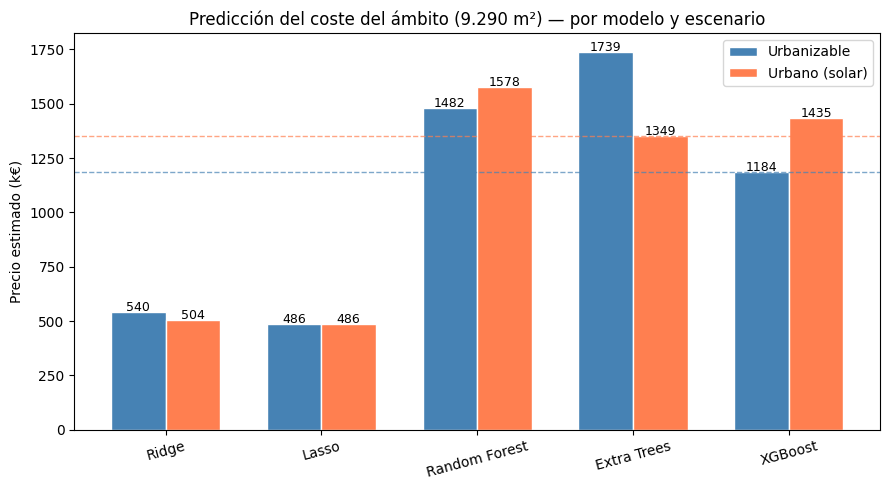

In [51]:
# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pred_df))

if has_urbanizable:
    w = 0.35
    b1 = ax.bar(x - w/2, pred_df['Predicción urbanizable (€)']/1000, w,
                label='Urbanizable', color='steelblue', edgecolor='white')
    b2 = ax.bar(x + w/2, pred_df['Predicción urbano (€)']/1000, w,
                label='Urbano (solar)', color='coral', edgecolor='white')
    ax.axhline(mediana_urbz/1000, color='steelblue', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mediana_urb/1000,  color='coral',     linestyle='--', linewidth=1, alpha=0.7)
    bars = [*b1, *b2]
    ax.set_title('Predicción del coste del ámbito (9.290 m²) — por modelo y escenario')
else:
    bars = ax.bar(x, pred_df['Predicción urbano (€)']/1000,
                  label='Urbano (solar)', color='coral', edgecolor='white')
    ax.axhline(mediana_urb/1000, color='coral', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title('Predicción del coste del ámbito (9.290 m²) — suelo urbano (solar)')

ax.set_xticks(x)
ax.set_xticklabels(pred_df.index, rotation=15)
ax.set_ylabel('Precio estimado (k€)')
ax.legend()

# Etiquetas
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+5, f'{h:.0f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Valor final adoptado y horquilla de incertidumbre

El valor central adoptado para el coste de adquisición del suelo se toma directamente de la predicción para el escenario **urbanizable** (si está disponible). En ausencia de esa categoría, se toma el escenario urbano (solar).

In [52]:
# Valor final = predicción directa (sin ajustes hedónicos)
if has_urbanizable:
    valor_base = pred_df['Predicción urbanizable (€)'].median()
    escenario_base = 'urbanizable'
    lower = pred_df['Predicción urbanizable (€)'].min()
    upper = pred_df['Predicción urbanizable (€)'].max()
else:
    valor_base = pred_df['Predicción urbano (€)'].median()
    escenario_base = 'urbano_solar'
    lower = pred_df['Predicción urbano (€)'].min()
    upper = pred_df['Predicción urbano (€)'].max()

valor_central = round(valor_base, -3)  # redondeo al millar

print('='*70)
print(f'  VALOR FINAL ADOPTADO PARA EL COSTE DEL SUELO DEL ÁMBITO')
print('='*70)
print(f'  Escenario base:          {escenario_base}')
print(f'  Valor central:           {valor_central:>12,.0f} €')
print(f'  Repercusión:             {valor_central/9290:>12.1f} €/m²')
print(f'  Horquilla (min-max):     [{lower:>10,.0f} - {upper:>10,.0f}] €')
print(f'  Horquilla €/m²:          [{lower/9290:>10.1f} - {upper/9290:>10.1f}]')
print('='*70)

# Resumen exportable a JSON
resumen_final = {
    'valor_central_eur':       float(valor_central),
    'valor_central_eur_m2':    float(valor_central/9290),
    'horquilla_inf_eur':       float(lower),
    'horquilla_sup_eur':       float(upper),
    'mediana_modelos_urbanizable_eur': float(mediana_urbz) if has_urbanizable else None,
    'mediana_modelos_urbano_eur': float(mediana_urb),
    'escenario_base':          escenario_base,
    'modelos_utilizados':       list(modelos.keys()),
    'r2_test_modelos':          {k: float(v) for k, v in resumen['R2_test'].items()},
}

  VALOR FINAL ADOPTADO PARA EL COSTE DEL SUELO DEL ÁMBITO
  Escenario base:          urbanizable
  Valor central:              1,184,000 €
  Repercusión:                    127.4 €/m²
  Horquilla (min-max):     [   485,751 -  1,739,038] €
  Horquilla €/m²:          [      52.3 -      187.2]
